# Photometric Calibration

## 1. Load data

In [ ]:
from ezphot.utils import DataBrowser
databrowser = DataBrowser('scidata')
databrowser.objname = 'T00528'
databrowser.filter = 'r'
target_imgset = databrowser.search('*100.fits', 'science')
target_imglist = target_imgset.target_images

(<Figure size 800x600 with 2 Axes>,
 <WCSAxes: title={'center': 'calib_7DT16_T00528_20250905_000408_r_100.fits'}>)

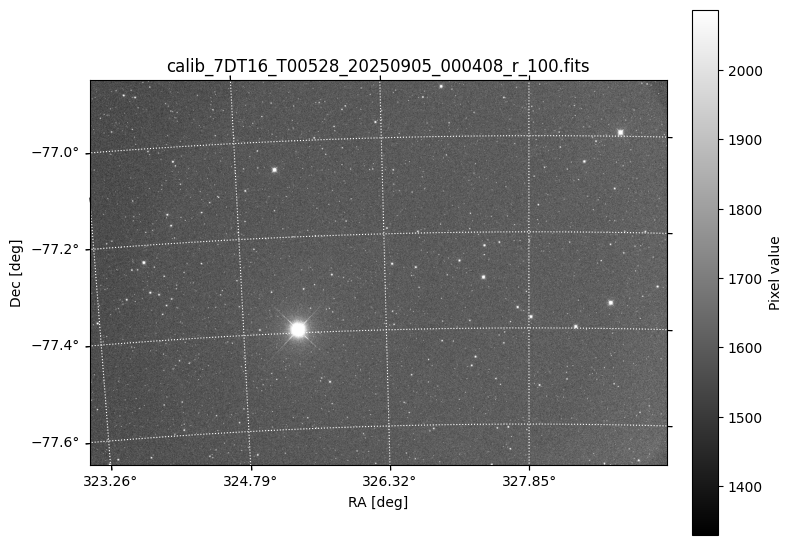

In [3]:
target_img = target_imglist[0]
target_img.show('coord')

Added circular mask at (325.37, -77.39) with radius 500arcsec


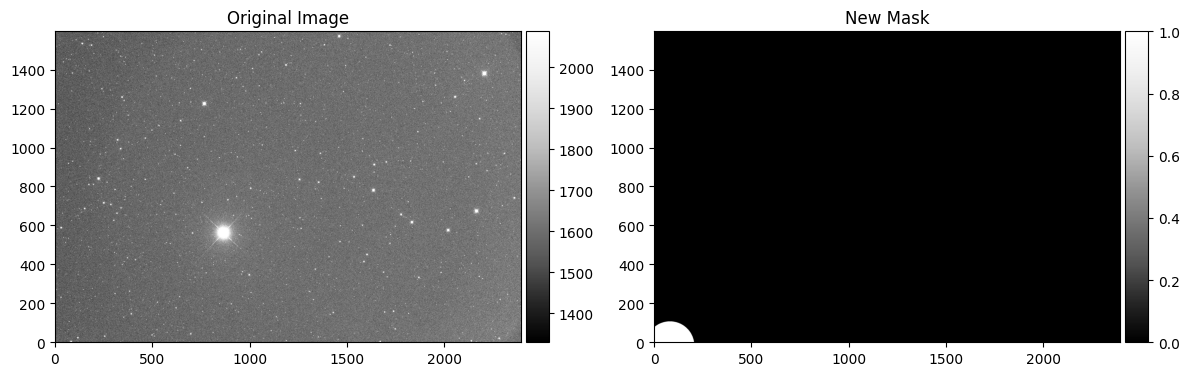

NameError: name 'verbose' is not defined

In [5]:
target_srcmask = None
target_srcmask = target_img.calculate_circularmask(
    target_mask = None,
    x_position = 325.37,
    y_position = -77.39,
    radius_arcsec = 500,
    unit = 'coord',
    save = False,
    verbose = True,
    visualize = True,
    save_fig = False
)
target_srcmask = target_img.calculate_sourcemask(
    target_srcmask = target_srcmask,
    save = True,
    verbose = verbose,
    visualize = visualize,
    save_fig = save_fig
)
target_img.clear()
target_srcmask.clear()

In [ ]:
target_bkg = target_img.calculate_bkg(
    target_srcmask = target_img.sourcemask,
    target_ivpmask = None,
    is_2D_bkg = True,
    box_size = 128,
    filter_size = 3,
    save = True,
    verbose = verbose,
    visualize = visualize,
    save_fig = save_fig
)
target_img.clear()
target_bkg.clear()


In [9]:
from ezphot.methods import Preprocess
preprocessor = Preprocess()
for target_img in target_imglist:
    from ezphot.imageobjects import CalibrationImage
    bias_tbl = preprocessor.get_masterframe_from_image(
        target_img = target_img,
        imagetyp = 'bias',
        max_days = 100
    )
    dark_tbl = preprocessor.get_masterframe_from_image(
        target_img = target_img,
        imagetyp = 'dark',
        max_days = 100
    )
    flat_tbl = preprocessor.get_masterframe_from_image(
        target_img = target_img,
        imagetyp = 'flat',
        max_days = 100
    )
    mbias = CalibrationImage(bias_tbl[0]['file'])
    mdark = CalibrationImage(dark_tbl[0]['file'])
    mflat = CalibrationImage(flat_tbl[0]['file'])
    target_bkgrms = target_img.calculate_bkgrms_from_propagation(
        target_bkg = target_img.bkgmap,
        mbias = mbias,
        mdark = mdark,
        mflat = mflat,
        mflaterr = None,
        ncombine = 1,
        readout_noise = target_img.telinfo['readnoise'],
        save = True,
        verbose = verbose,
        visualize = visualize,
        save_fig = save_fig
    )